## ProSafe Feature Importance and Predictive Modeling

In the following Jupyter notebook, our team will analyze the features of the ProSafe dataset – our selected synthetic dataset – to aid us when performing predictive modeling on the dataset.

As with the start of any project, we must first import the necessary dependencies. This process was similar to the Allstate analysis, but we also added matplotlib in this case to better-visualize the feature importances.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelBinarizer,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

The following set of instructions printed out the current working directory and its corresponding files. This would then aid us in importing the necessary datasets into Pandas.

In [2]:
import os
print(os.getcwd())
print(os.listdir())

/Volumes/Workspace/code/comp-sci-464/uwgb-comp-sci-464-group-project
['requirements.txt', 'prosafe_feature_importance_predictive_modeling.ipynb', 'prosafe_predictive_modeling_knn.ipynb', 'docs', '.gitignore', 'README.md', 'examples', 'mnist_assignment', 'allstate_feature_analysis.ipynb', 'data_sources', '.git', 'CODEOWNERS', '.idea']


In [3]:
base_dir = "./data_sources/prosafe_dataset"
policy_from_2011_to_2014 = pd.read_csv(f"{base_dir}/policy_from_2011_to_2014.csv")
policy_from_2014_to_2018 = pd.read_csv(f"{base_dir}/policy_from_2014_to_2018.csv")

As the start of the data cleaning and sanitation process, our team selected the input and output variables for the model. To start, we selected the `PREMIUM` as the only output variable, leaving us with all other columns as input features. We would later drop certain columns from the feature analysis when it became clear that such features were unhelpful, but this served as a foundation for our analysis.

In [4]:
# Step 1: Choose Input Feature(s) and Corresponding Predicted Output Feature

target_col = "PREMIUM"

y = policy_from_2011_to_2014['PREMIUM']
X = policy_from_2011_to_2014.drop(columns=['PREMIUM'])

Then, our group decided to drop certain columns where more than 50% of the entries had missing values. Although these columns could have been used in our analysis, it would require special processing techniques to be able to add certain values that were otherwise left blank. To keep things simple, we decided to drop these columns in our specific analysis.

Finally, we had to convert certain columns (including date-time columns) into a proper format. After this, we were able to create the train-test split that we would use for our model and our dataset was ready.

In [5]:
# 0. DROP features with >50% missing values (and CCM_TON you decided to drop)
X = X.drop(columns=['CCM_TON', 'CARRYING_CAPACITY', 'CLAIM_PAID'])

# Drop rows where target PREMIUM (y) is NaN
mask = y.notna()
X = X.loc[mask].copy()
y = y.loc[mask].copy()

# Fix EFFECTIVE_YR
X['EFFECTIVE_YR'] = pd.to_numeric(X['EFFECTIVE_YR'], errors='coerce')
X['EFFECTIVE_YR'] = X['EFFECTIVE_YR'].fillna(X['EFFECTIVE_YR'].median())

# Fix a few other numeric columns with small NaN counts
X['SEATS_NUM'] = X['SEATS_NUM'].fillna(X['SEATS_NUM'].median())
X['PROD_YEAR'] = X['PROD_YEAR'].fillna(X['PROD_YEAR'].median())

# Date columns → ordinals
date_cols = ["INSR_BEGIN", "INSR_END"]
for col in date_cols:
    X[col] = pd.to_datetime(X[col], format='%d-%b-%y', errors='coerce')
    X[col] = X[col].map(lambda x: x.toordinal() if pd.notnull(x) else np.nan)

# Fill any remaining numeric NaNs (e.g., from bad dates)
X = X.fillna(X.median(numeric_only=True))

# One-hot encode categoricals
cat_cols = ['TYPE_VEHICLE', 'MAKE', 'USAGE']
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Final sanity check


# 2. Split AFTER preprocessing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (234823, 487)
X_test shape: (58706, 487)


In [6]:
# 1. See which columns are still object (string) type
obj_cols = X_train.select_dtypes(include=['object']).columns
print("Object columns:", list(obj_cols))

Object columns: []


### Feature Importance Analysis

Similar to the Allstate analysis, we leveraged a random forest regressor to analyze the different input features for the ProSafe dataset – which we later used to create a graph using `matplotlib`. As can be seen, this model can also be used in and of itself to predict values, although we used other techniques – such as SVR and linear regression – to perform our main predictive modeling evaluation.

In [7]:
# TRAIN

rf = RandomForestRegressor(
    n_estimators=50,    # way fewer trees than 300
    max_depth=15,       # cap tree depth
    max_features='sqrt',# try fewer features per split
    n_jobs=-1,          # all cores
    random_state=42
)

rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
print("R²:", r2_score(y_test, y_pred))

R²: 0.6688144546433619


In [8]:
# obtain importances for  Random Forest
importances_rf = rf.feature_importances_

feature_importance_rf = pd.Series(importances_rf, index=X.columns)

print("Random Forest Feature Importance: ")
print(feature_importance_rf.sort_values(ascending=False)[0:10])

Random Forest Feature Importance: 
INSURED_VALUE               0.332688
USAGE_General Cartage       0.089260
PROD_YEAR                   0.063989
SEATS_NUM                   0.055489
TYPE_VEHICLE_Truck          0.055395
MAKE_IVECO                  0.037362
TYPE_VEHICLE_Motor-cycle    0.030403
INSR_END                    0.028472
SEX                         0.026138
MAKE_ISUZU                  0.023729
dtype: float64


Once the random forest regressor has been properly trained, a graph can be created based on the feature importances like so:

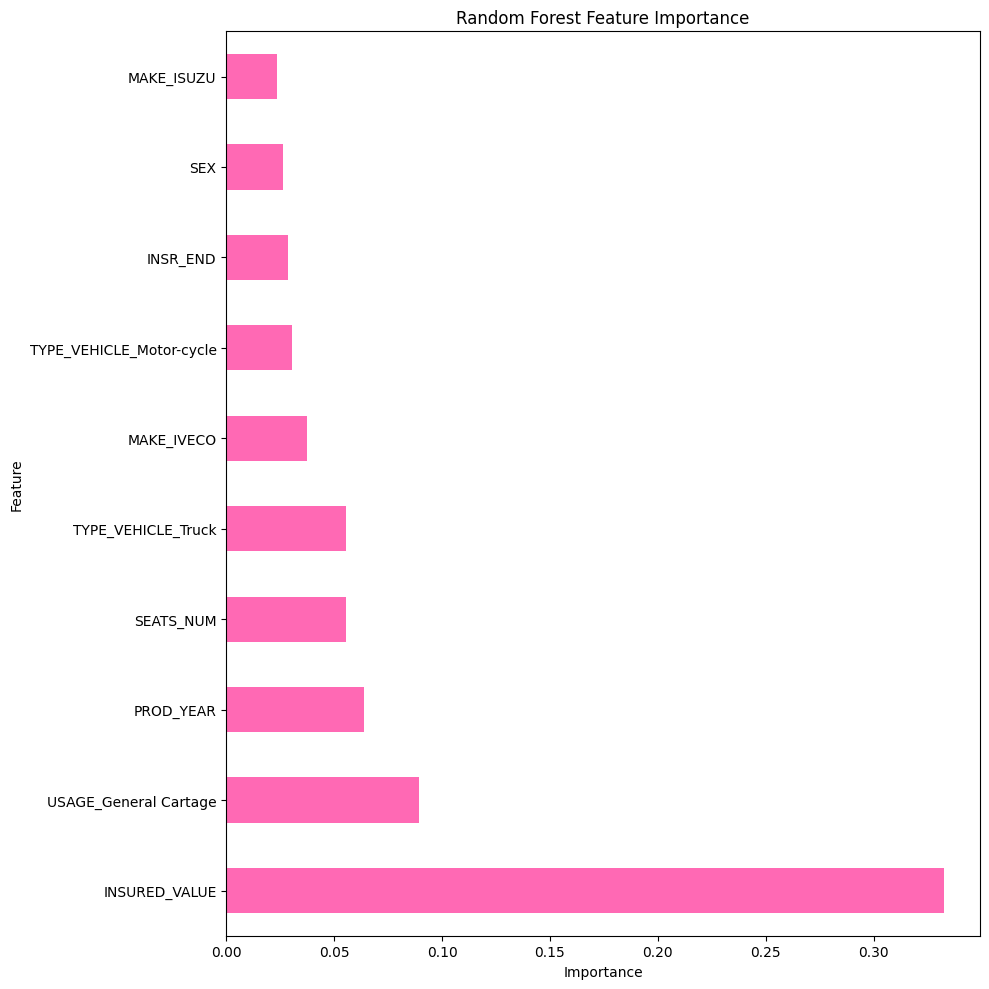

In [9]:
# visualization of the Random Forest importances
plt.figure(figsize=(10, 10))
feature_importance_rf.sort_values(ascending=False)[0:10].plot(kind='barh', color='hotpink')
plt.title("Random Forest Feature Importance")
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Predictive Modeling using Linear Regression and SVR

The two Machine Learning models our team decided to use in our predictive modeling analysis include Linear Regression and Support Vector Regression. Linear Regression – being a simple statistical technique – required no hyperparameters, so it was easy to get started with. Shown below is the code we used for our Linear Regression model:

In [10]:
# Linear Regression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
y_pred = linear_regression.predict(X_test)

print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))
print("Mean Absolute Error (MAE)", mean_absolute_error(y_test, y_pred))

Mean Squared Error (MSE): 31640670.502350092
R^2 Score: 0.6043741375044147
Mean Absolute Error (MAE) 3402.4925735757024


Support Vector Machines (Regression), on the other hand, required a kernel to define how the model was to be trained. We decided to keep the hyperparameters that tweak the hyperplane as the default (namely, the `C`, `gamma`, and others) as these can be challenging to tune and get right.

Our group chose the Linear kernel as our group believed this kernel would fit better with the given data – as the data tended to be more-predictable and less complex. However, it became clear that even a Linear kernel was very slow to train using a Support Vector Regressor. As a result, we had to take a unique subset of the dataset to train the data for the sake of this exercise.

Shown below is the code we used to train and evaluate our model:

In [12]:
# SVR
X_subset = X[0:100]
y_subset = y[0:100]
X_train, X_test, y_train, y_test = train_test_split(X_subset, y_subset, test_size=0.2, random_state=42)
svr = SVR(kernel='linear')
svr.fit(X_train, np.ravel(y_train))

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [13]:
y_pred = svr.predict(X_test)

print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))
print("Mean Absolute Error (MAE)", mean_absolute_error(y_test, y_pred))

Mean Squared Error (MSE): 4.4447122672370666e+25
R^2 Score: -4.723875082270749e+17
Mean Absolute Error (MAE) 6492256440056.753


As can be seen in the example above, our SVR model did not perform as well as the Linear Regression model (even providing us a negative $R^2$ score). This makes sense since SVR is more-optimal for more-complex high-dimensional datasets, while Linear Regression is more optimal for simpler mathematical relationships – which seemed to be the case in our dataset.

However, such a model provided an example of how different models perform under the same dataset. It is always important to know and understand the nature of a dataset when choosing a model, as the results of the model – once trained – can differ wildly if the wrong technique is used.